In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("crypto_sentiment_prediction_dataset.csv")

df.head()

,timestamp,cryptocurrency,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,volatility_index,rsi_technical_indicator,prediction_confidence
0,2025-06-04 20:36:49,Algorand,0.3427,-5.35,1716266.10,1.762124e+09,0.367,0.374,1.87,13,53.2,95.1,37.2,78.1
1,2025-06-04 20:48:25,Cosmos,12.0420,5.14,10520739.91,2.099178e+11,-0.278,-0.107,1.01,600,43.5,76.7,65.0,66.7
2,2025-06-04 21:28:54,Cosmos,11.7675,-6.12,642191.11,1.755367e+11,-0.255,0.211,5.69,279,49.1,60.4,32.3,77.4
3,2025-06-04 21:57:48,Ethereum,2861.2829,-11.54,5356227.76,4.786419e+13,-0.531,-0.081,5.11,3504,37.0,100.0,63.0,81.7
4,2025-06-04 22:06:40,Solana,95.3583,5.79,735971.56,2.667611e+11,0.369,0.248,1.82,3236,61.7,67.5,55.4,81.8


In [4]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2063 entries, 0 to 2062
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 2063 non-null   object 
 1   cryptocurrency            2063 non-null   object 
 2   current_price_usd         2063 non-null   float64
 3   price_change_24h_percent  2063 non-null   float64
 4   trading_volume_24h        2063 non-null   float64
 5   market_cap_usd            2063 non-null   float64
 6   social_sentiment_score    2063 non-null   float64
 7   news_sentiment_score      2063 non-null   float64
 8   news_impact_score         2063 non-null   float64
 9   social_mentions_count     2063 non-null   int64  
 10  fear_greed_index          2063 non-null   float64
 11  volatility_index          2063 non-null   float64
 12  rsi_technical_indicator   2063 non-null   float64
 13  prediction_confidence     2063 non-null   float64
dtypes: float

,0
timestamp,0
cryptocurrency,0
current_price_usd,0
price_change_24h_percent,0
trading_volume_24h,0
market_cap_usd,0
social_sentiment_score,0
news_sentiment_score,0
news_impact_score,0
social_mentions_count,0


In [5]:
df["cryptocurrency"].value_counts()

,count
cryptocurrency,
Ethereum,228
Avalanche,221
Polygon,217
Chainlink,210
Cosmos,206
Polkadot,204
Algorand,202
Solana,199
Cardano,198


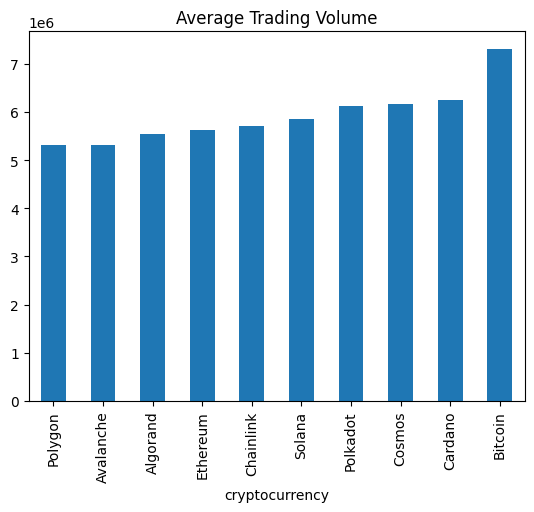

In [6]:
volume = df.groupby("cryptocurrency")["trading_volume_24h"].mean().sort_values()

volume.plot(kind="bar")
plt.title("Average Trading Volume")
plt.show()

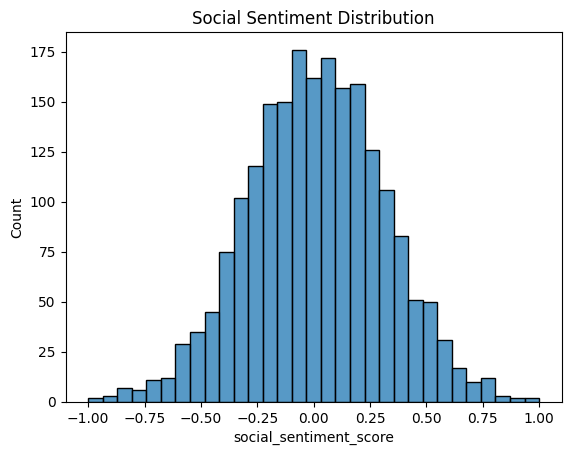

In [7]:
sns.histplot(df["social_sentiment_score"])
plt.title("Social Sentiment Distribution")
plt.show()

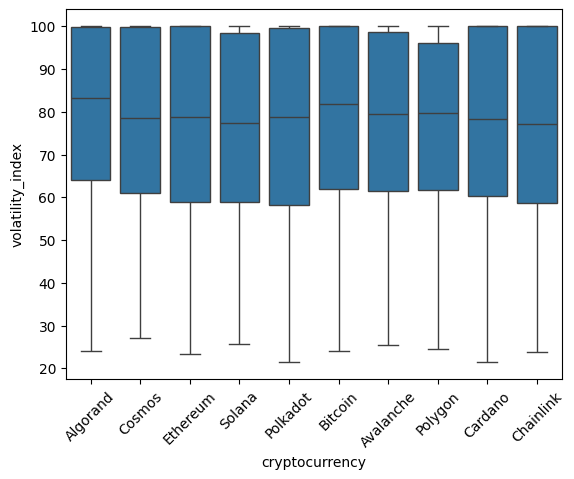

In [8]:
sns.boxplot(
    x="cryptocurrency",
    y="volatility_index",
    data=df
)

plt.xticks(rotation=45)
plt.show()

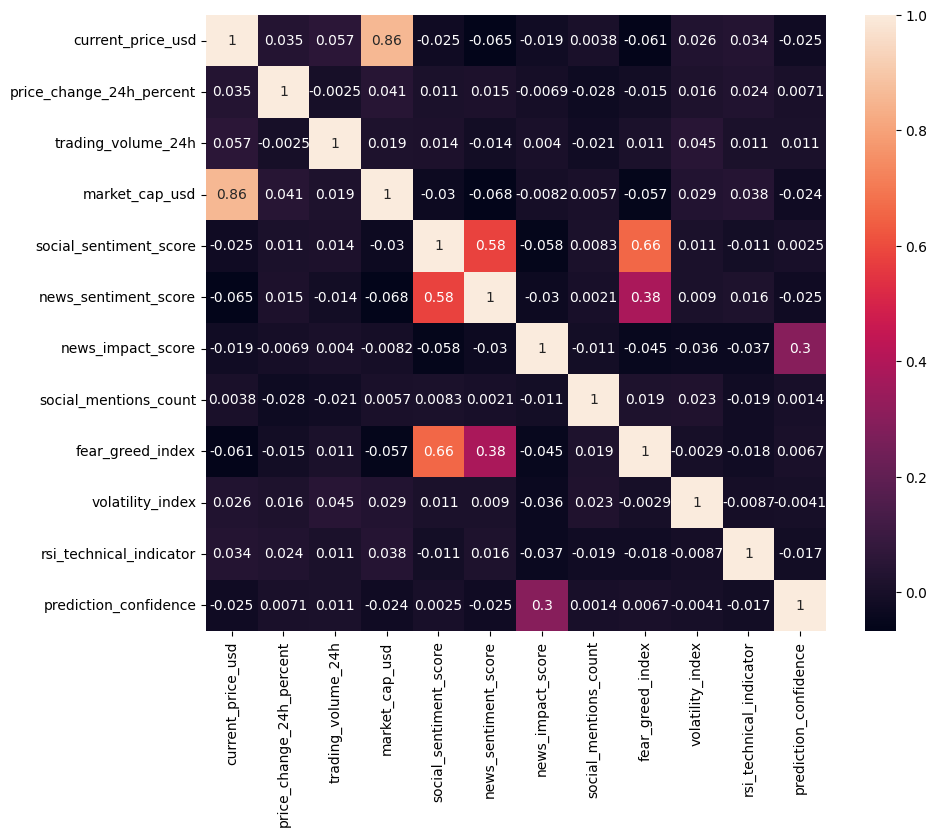

In [9]:
numeric_cols = df.select_dtypes(include=np.number)

corr = numeric_cols.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)
plt.show()

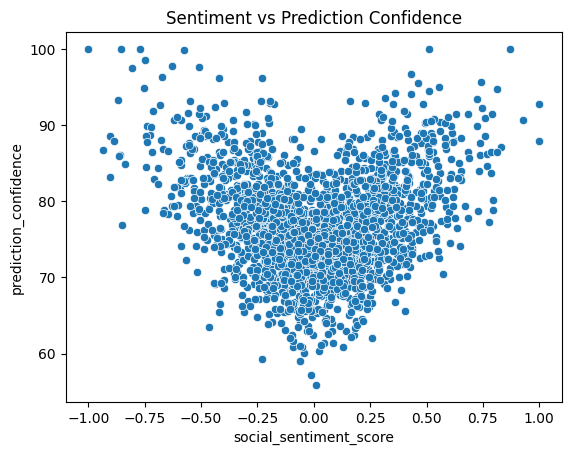

In [10]:
sns.scatterplot(
    x="social_sentiment_score",
    y="prediction_confidence",
    data=df
)

plt.title("Sentiment vs Prediction Confidence")
plt.show()